## Step:1
Computation of PCA

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.graph_objects as go

# Download S&P 500 sector ETF data for PCA analysis
tickers = ['XLK', 'XLV', 'XLF', 'XLE', 'XLI', 'XLY', 'XLP', 'XLU', 'XLB', 'XLRE']
data = yf.download(tickers, start='2020-01-01', end='2025-12-01')['Close']

# Compute daily log returns 
log_returns = np.log(data / data.shift(1)).dropna()
print("Dataset shape:", log_returns.shape)
print("\nCorrelation matrix preview:")
print(log_returns.corr().round(3))

/tmp/ipython-input-1019914277.py:14: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start='2020-01-01', end='2025-12-01')['Close']
[*********************100%***********************]  10 of 10 completed

Dataset shape: (1485, 10)

Correlation matrix preview:
Ticker    XLB    XLE    XLF    XLI    XLK    XLP   XLRE    XLU    XLV    XLY
Ticker                                                                      
XLB     1.000  0.679  0.851  0.896  0.700  0.676  0.748  0.630  0.719  0.745
XLE     0.679  1.000  0.712  0.696  0.438  0.422  0.497  0.424  0.467  0.474
XLF     0.851  0.712  1.000  0.898  0.667  0.661  0.730  0.615  0.697  0.728
XLI     0.896  0.696  0.898  1.000  0.736  0.681  0.762  0.654  0.722  0.777
XLK     0.700  0.438  0.667  0.736  1.000  0.546  0.622  0.484  0.653  0.841
XLP     0.676  0.422  0.661  0.681  0.546  1.000  0.717  0.740  0.755  0.567
XLRE    0.748  0.497  0.730  0.762  0.622  0.717  1.000  0.768  0.724  0.669
XLU     0.630  0.424  0.615  0.654  0.484  0.740  0.768  1.000  0.664  0.490
XLV     0.719  0.467  0.697  0.722  0.653  0.755  0.724  0.664  1.000  0.625
XLY     0.745  0.474  0.728  0.777  0.841  0.567  0.669  0.490  0.625  1.000


### Data Preprocessing

In [2]:
# Standardize returns for PCA 
scaler = StandardScaler()
returns_scaled = scaler.fit_transform(log_returns)

# Verify standardization
print("Mean of scaled data:", returns_scaled.mean(axis=0).round(4))
print("Std of scaled data:", returns_scaled.std(axis=0).round(4))

Mean of scaled data: [ 0.  0. -0.  0. -0.  0.  0. -0. -0. -0.]
Std of scaled data: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


### PCA Computation


In [ ]:
# Fit PCA with all components
pca = PCA()
pca.fit(returns_scaled)

# Explained variance analysis
explained_var = pca.explained_variance_ratio_
cumulative_var = np.cumsum(explained_var)

print("Explained variance by first 5 components:")
for i in range(5):
    print(f"PC{i+1}: {explained_var[i]:.3f} ({cumulative_var[i]:.3f} cumulative)")

# Select 3 components
pca_3 = PCA(n_components=3)
pc_scores_3 = pca_3.fit_transform(returns_scaled)


Explained variance by first 5 components:
PC1: 0.704 (0.704 cumulative)
PC2: 0.087 (0.791 cumulative)
PC3: 0.071 (0.862 cumulative)
PC4: 0.034 (0.896 cumulative)
PC5: 0.025 (0.921 cumulative)


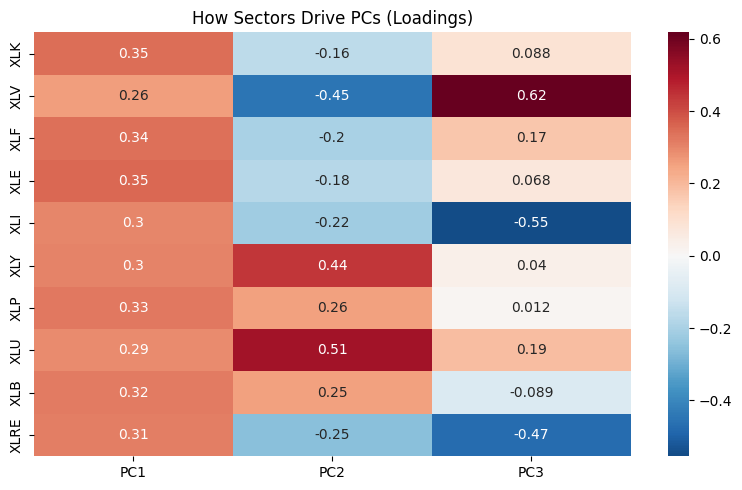

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# 1. LOADINGS HEATMAP: HOW sectors contribute to each PC
loadings = pd.DataFrame(pca_3.components_.T, columns=['PC1', 'PC2', 'PC3'], index=tickers)
plt.figure(figsize=(8, 5))
sns.heatmap(loadings, annot=True, cmap='RdBu_r', center=0)
plt.title('How Sectors Drive PCs (Loadings)')
plt.tight_layout()
plt.show()

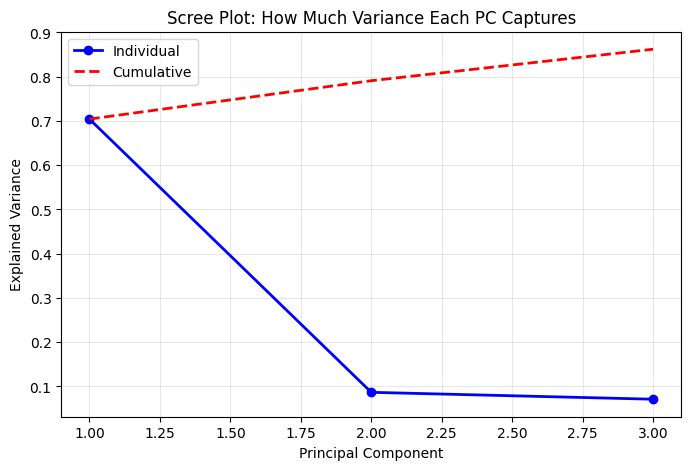

In [10]:

# 2. SCREE PLOT: Variance explained by each PC
plt.figure(figsize=(8, 5))
plt.plot(range(1, 4), pca_3.explained_variance_ratio_, 'bo-', linewidth=2)
plt.plot(range(1, 4), np.cumsum(pca_3.explained_variance_ratio_), 'r--', linewidth=2)
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance')
plt.title('Scree Plot: How Much Variance Each PC Captures')
plt.legend(['Individual', 'Cumulative'])
plt.grid(True, alpha=0.3)
plt.show()

In [16]:
# 3. 3D PCA SPACE: Data geometry in reduced dimensions
fig = px.scatter_3d(
    x=pc_scores_3[:,0], y=pc_scores_3[:,1], z=pc_scores_3[:,2],
    color=np.arange(len(pc_scores_3)),  # Color by time (1485 points)
    title='3D PCA: How Original Data Maps to PC Space',
    labels={'color': 'Time Index'}
)
fig.show()